In [2]:
import pandas as pd
from pathlib import Path
from datetime import datetime
from torch.utils.data import DataLoader
from amoc_reconstruction.reconstruction.model import init_assignment_module
from amoc_reconstruction.reconstruction.model import ProfileModelSUSTeR5_fast, ProfileModelSUSTeR6, ProfileModelSUSTeR7
from amoc_reconstruction.train import train, make_predictions
from amoc_reconstruction.reconstruction.dataset import merge_profiles_max_profiles
from amoc_reconstruction.reconstruction.dataset import load_merged_argo_dataset_and_tumo_cycles, filter_ds_argo_data, split_dataset_into_training_validation_testing_profile_datasets
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import torch

In [8]:
### PARAMETERS

smoothing_days = 90

time_smoothing = f'{smoothing_days}D'
lat_bounds = (25, 30)

test_start_year = 2005
test_end_year = 2020
validation_years_on_each_side = 10


target_reference_level = 4800

missing_values_in_target = False


using_missing_indices = False
using_transport_from_previous_year = False
use_deep_dvdz = False
deep_argo = True

geostrophic_prediction = False


train_batch_sizes = {
    '10D': 32,
    '30D': 16,
    '90D': 8,
    '365D': 4,
}


n_compartments_for_smoothing = {
    '10D': 49,
    '30D': 3,
    '90D': 9,
    '365D': 42,
}

train_batch_size = train_batch_sizes[time_smoothing]

add_tmp = False
add_sal = False

test_start_year = 2005
test_end_year = 2025

validation_years_on_each_side = 5


random_split_data = False

assert target_reference_level in [2000, 4800], "Only 2000 and 4800 are supported as reference levels"
version = 'v5'
n_compartments = n_compartments_for_smoothing[time_smoothing]
n_embedding = 8

distance_assignment_module  = 'distance'

experiment_path = Path(f'../rapid-geostrophic-reconstruction/figs/experiment_{datetime.now().strftime("%Y%m%d_%H%M%S")}')
dataset_path = Path(f'../rapid-geostrophic-reconstruction/datasets/smoothing_{smoothing_days}_days/argo_after_2012/paperdraft/')

total_moc_path = Path('../rapid-geostrophic-reconstruction/datasets/moc_total/')
antilles_current_path = Path('../rapid-geostrophic-reconstruction/datasets/antilles_current/')
florida_current_path = Path('../rapid-geostrophic-reconstruction/datasets/florida_current/')
wind_stress_path = Path('../rapid-geostrophic-reconstruction/datasets/windstress/')

ref_folder = f'{abs(target_reference_level)}m_ref'

compartments = [
        ['west_p', -76.74, -70, 'west'],
        ['mar_west_p', -60, -47, 'east'],
        ['mar_east_p', -47, -40, 'west'],
        ['east_p', -30, -13.5, 'east']
    ]


device = 'cpu'


assert version in ['v2', 'v3', 'v4', 'v5']
assert distance_assignment_module in ['distance', 'fixed']



### Experiment 20012025


- First we need to find the most promising method for the recosntruction. 
- Therefore we will reconstruct the 90 days scales in multiple configurations: 
    - Model v6 
    - Model v5 argo_mean + std with n_compartments = [1,3,5,7,11,17]
    - Model v5 argo_std with n_compartments = [1,3,5,7,11,17]
    - Model v5 argo_std with n_compartments = [1,3,5,7,11,17] and argo_mean in the embedding

- Each run is executed 3 times and the mean and std is reported
- test period from 2005 to 2025 with 5 years validation at each side
- three different random seeds 

In [4]:
import numpy as np

n_iters = 3
random_seeds = np.random.randint(0, 1000, n_iters)

random_seeds

array([687,  50, 399])

In [9]:



ds_argo_merged, t_umo_obs, ds_pos_sim, dv_dz_obs, t_delta, total_moc, antilles_current, florida_current, wind_stress = load_merged_argo_dataset_and_tumo_cycles(
    ['1st_7024', '2nd_5824'],
    dataset_path,
    ref_folder,
    total_moc_path,
    antilles_current_path,
    florida_current_path,
    wind_stress_path,
    time_smoothing,
    deep_argo,
    missing_values_in_target
)


ds_argo_merged = filter_ds_argo_data(ds_argo_merged, deep_argo)





train_dataset, val_dataset, test_dataset, (total_moc_mean, total_moc_std, geostrophic_moc_mean, geostorphic_moc_std) = split_dataset_into_training_validation_testing_profile_datasets(
    False, test_start_year, test_end_year, validation_years_on_each_side, t_umo_obs, ds_argo_merged, add_tmp, add_sal, deep_argo, False, total_moc, florida_current, antilles_current, wind_stress, dv_dz_obs, missing_values_in_target, ds_pos_sim, compartments, time_smoothing, lat_bounds, using_transport_from_previous_year, using_missing_indices, use_deep_dvdz
)


dl = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True, collate_fn=merge_profiles_max_profiles, num_workers=8)
val_dl = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles_max_profiles, num_workers=4)
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles_max_profiles, num_workers=4)


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


ValueError: too many values to unpack (expected 9)

In [6]:


n_features = train_dataset.X.shape[2]

models = []

for version in ['v5-full', 'v5-std-embedmean', 'v5-std']:
# for version in ['v7-std', 'v7-std-embedmean']:


    # n_compartments_list = [1,3,5,7,11,17]
    n_compartments_list = [42]

    if version.startswith('v6'):
        n_compartments_list = [1]


    if version == 'v5-full':
        argo_mean_in_gnn = True
        argo_mean_in_embedding = False
    elif version == 'v5-std':
        argo_mean_in_gnn = False
        argo_mean_in_embedding = False
    elif version == 'v5-std-embedmean':
        argo_mean_in_gnn = False
        argo_mean_in_embedding = True
    if version == 'v7-full':
        argo_mean_in_gnn = True
        argo_mean_in_embedding = False
    elif version == 'v7-std':
        argo_mean_in_gnn = False
        argo_mean_in_embedding = False
    elif version == 'v7-std-embedmean':
        argo_mean_in_gnn = False
        argo_mean_in_embedding = True

    for n_compartments in n_compartments_list:
        r2_scores = []
        mae_scores = []
        mse_scores = []

        for i in range(n_iters):

            torch.random.manual_seed(random_seeds[i])
            np.random.seed(random_seeds[i])

            node_assigner = init_assignment_module(distance_assignment_module, train_dataset, n_compartments, device)
            if version.startswith('v5'):
                model = ProfileModelSUSTeR5_fast(
                    n_features, n_compartments,n_embedding, 
                    train_dataset.dv_dz.shape[1] , dv_dz_obs.z, device, profile_embedder=None, node_assigner= node_assigner,
                    argo_mean_in_embedding=argo_mean_in_embedding, argo_mean_in_gnn_input=argo_mean_in_gnn, assignment_threshold= .15, adj_threshold=.3, num_gcn_layers= 3 ).to(device)
            elif version.startswith('v7'):
                model = ProfileModelSUSTeR7(
                    n_features, n_compartments,n_embedding, 
                    train_dataset.dv_dz.shape[1] , dv_dz_obs.z, device, profile_embedder=None, node_assigner= node_assigner,
                    argo_mean_in_embedding=argo_mean_in_embedding, argo_mean_in_gnn_input=argo_mean_in_gnn).to(device)
            elif version.startswith('v6'):
                model = ProfileModelSUSTeR6(
                    n_features, n_compartments,n_embedding, 
                    train_dataset.dv_dz.shape[1] , dv_dz_obs.z, device, profile_embedder=None, node_assigner= node_assigner).to(device)
            else:
                raise ValueError('Unknown version')





            best_model = train(model, dl, val_dl, device, verbose = True, geostrophic_target=geostrophic_prediction)
            models.append(best_model)


            if geostrophic_prediction:
                test_predictions, (test_hidden_spaces, test_embedding_spaces, test_gt_transport, test_inner_values) = make_predictions(test_dataset, best_model, ds_argo_merged.isel(time = test_dataset.global_indices).time, geostrophic_moc_mean, geostorphic_moc_std,device = device, geostrophic_target=True)
            else:
                test_predictions, (test_hidden_spaces, test_embedding_spaces, test_gt_transport, test_inner_values) = make_predictions(test_dataset, best_model, ds_argo_merged.isel(time = test_dataset.global_indices).time, total_moc_mean, total_moc_std,device = device)


            target_variable = test_gt_transport


            mae_error = mean_absolute_error(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)
            
            r2_scores.append(r2_score(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values))
            mae_scores.append(mae_error)
            mse_scores.append(mean_squared_error(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values))
            
            print(f'\t R2 {r2_scores[-1]*100:.2f}%; MAE {mae_scores[-1]:.2f}; MSE {mse_scores[-1]:.2f}')

            break

        print(f'{version} {f"- {n_compartments} compartments" if version.startswith("v5") else ""} -' +
              f'R2 mean {np.mean(r2_scores)*100:.2f}% std {np.std(r2_scores)*100:.2f}%; ' +
              f'MAE mean {np.mean(mae_scores):.2f} std {np.std(mae_scores):.2f}; ' +
              f'MSE mean {np.mean(mse_scores):.2f} std {np.std(mse_scores):.2f}; ')



mean_cluster_init_distance tensor(0.0238, dtype=torch.float64)
New best model found in epoch:  0 with val loss:  0.4278130531311035
New best model found in epoch:  1 with val loss:  0.255388792604208
Epoch 2, Loss: 0.5169106219773707, Val loss: 0.29965242743492126, current learning rate: 9.99E-04
New best model found in epoch:  3 with val loss:  0.2129698395729065
New best model found in epoch:  4 with val loss:  0.19857699424028397
Epoch 5, Loss: 0.43118448490681854, Val loss: 0.24440858513116837, current learning rate: 9.98E-04
Epoch 8, Loss: 0.364680665747627, Val loss: 0.20480526983737946, current learning rate: 9.95E-04
New best model found in epoch:  11 with val loss:  0.18191322311758995
Epoch 11, Loss: 0.33987522513970087, Val loss: 0.18191322311758995, current learning rate: 9.91E-04
Epoch 14, Loss: 0.27448530397985293, Val loss: 0.19258690625429153, current learning rate: 9.86E-04
New best model found in epoch:  15 with val loss:  0.1783558428287506
Epoch 17, Loss: 0.27256510

In [ ]:
test_predictions, (test_hidden_spaces, test_embedding_spaces, test_gt_transport, test_inner_values) = make_predictions(test_dataset, best_model, ds_argo_merged.isel(time = test_dataset.global_indices).time, total_moc_mean, total_moc_std,device = device)

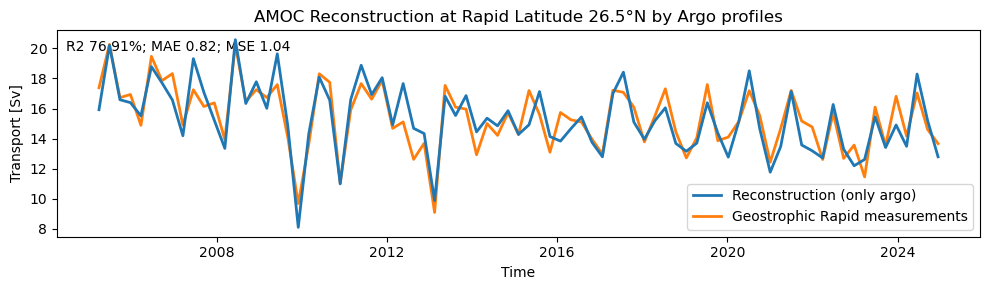

In [ ]:
from amoc_reconstruction.utils.plots import prediction_plot

prediction_plot(test_gt_transport, test_predictions)

In [7]:
mean_profiles = ds_argo_merged.rho.sum('pos') / ds_argo_merged.profile_mask.sum('pos')

In [8]:
total_moc_max = total_moc.sel(depthw = -1000, method='nearest').zomsfatl
weak_moc = (total_moc_max - total_moc_mean) < - total_moc_std
weak_moc_mask = weak_moc.values


normal_moc = ((total_moc_max - total_moc_mean) <= total_moc_std) & ((total_moc_max - total_moc_mean) >= - total_moc_std)
normal_moc_mask = normal_moc.values

strong_moc = (total_moc_max - total_moc_mean) > total_moc_std
strong_moc_mask = strong_moc.values


In [ ]:
weak_profiles = mean_profiles.isel(time = weak_moc_mask)#.mean('time')
normal_profiles = mean_profiles.isel(time = normal_moc_mask)
strong_profiles = mean_profiles.isel(time = strong_moc_mask)


In [ ]:
.shape

(69, 46)

torch.Size([32, 393, 29])
torch.Size([32, 409, 29])
torch.Size([17, 394, 29])


Text(0.5, 0, 'rho (z-norm)')

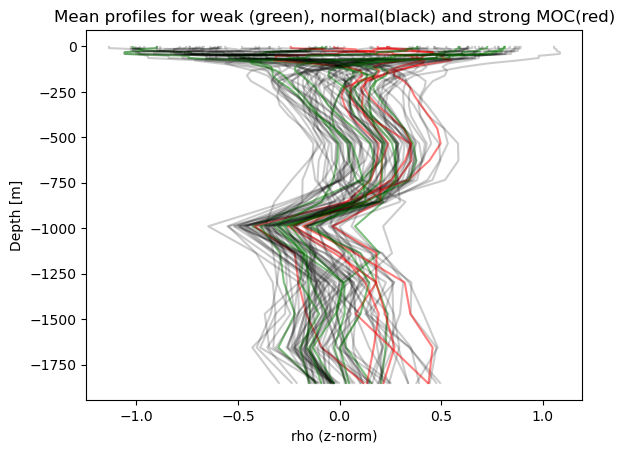

In [10]:
import matplotlib.pyplot as plt

for data in test_dl:
    X, mask_padded, y, y_prev, lon, lat, dvdz, days, missing_indices, fs, ac, ws, total_moc = data
    print(X.shape)

    argo_mean = torch.sum(X, dim=1) / torch.sum(mask_padded, dim=1, keepdim=True)

    argo_std = torch.sqrt(((X - argo_mean.unsqueeze(1)) ** 2).sum(dim = 1) / (torch.sum(mask_padded, dim=1, keepdim=True) - 1))

    mask = (argo_std < 5).all(1)

    argo_plot = argo_mean[mask]
    total_moc = total_moc[mask]

    weak_moc = total_moc < -1
    normal_moc = (total_moc >= -1) & (total_moc <= 1)
    strong_moc = total_moc > 1


    colors = weak_moc * 1.0 + normal_moc * 2.0 + strong_moc * 3.0

    plt.plot(argo_plot.detach().numpy()[weak_moc].T, np.tile(ds_argo_merged.z.values[np.newaxis], (weak_moc.sum(),1)).T, color = 'green', alpha = .5)
    plt.plot(argo_plot.detach().numpy()[normal_moc].T, np.tile(ds_argo_merged.z.values[np.newaxis], (normal_moc.sum(),1)).T, color = 'black', alpha = .2)
    plt.plot(argo_plot.detach().numpy()[strong_moc].T, np.tile(ds_argo_merged.z.values[np.newaxis], (strong_moc.sum(),1)).T, color = 'red', alpha = .5)

plt.title('Mean profiles for weak (green), normal(black) and strong MOC(red)')

plt.ylabel('Depth [m]')
plt.xlabel('rho (z-norm)')


tensor([True, True, True, True, True])

In [6]:
len(train_dataset)

228

In [18]:
ds_argo_merged.isel(time = train_dataset.global_indices).time.dt.year

<xarray.DataArray 'year' (time: 366)>
array([1970, 1970, 1970, ..., 2089, 2089, 2090])
Coordinates:
  * time     (time) datetime64[ns] 1970-01-01 1970-04-01 ... 2090-01-01

torch.Size([8, 383, 29])
torch.Size([8, 385, 29])
torch.Size([8, 405, 29])
torch.Size([8, 397, 29])
torch.Size([8, 395, 29])
torch.Size([8, 382, 29])
torch.Size([8, 364, 29])
torch.Size([8, 406, 29])
torch.Size([8, 390, 29])
torch.Size([8, 366, 29])
torch.Size([8, 394, 29])
torch.Size([8, 382, 29])
torch.Size([8, 389, 29])
torch.Size([8, 370, 29])
torch.Size([8, 387, 29])
torch.Size([8, 342, 29])
torch.Size([8, 397, 29])
torch.Size([8, 358, 29])
torch.Size([8, 408, 29])
torch.Size([8, 379, 29])
torch.Size([8, 405, 29])
torch.Size([8, 384, 29])
torch.Size([8, 396, 29])
torch.Size([8, 393, 29])
torch.Size([8, 384, 29])
torch.Size([8, 383, 29])
torch.Size([8, 374, 29])
torch.Size([8, 394, 29])
torch.Size([8, 391, 29])
torch.Size([8, 301, 29])
torch.Size([8, 358, 29])
torch.Size([8, 371, 29])
torch.Size([8, 384, 29])
torch.Size([8, 405, 29])
torch.Size([8, 354, 29])
torch.Size([8, 408, 29])
torch.Size([8, 391, 29])
torch.Size([8, 396, 29])
torch.Size([8, 383, 29])
torch.Size([8, 391, 29])


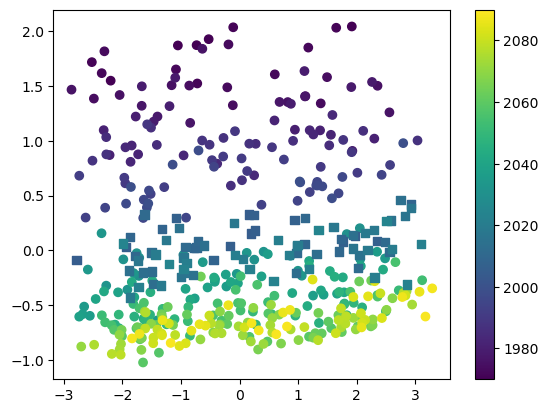

In [56]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
argo_means = []

moc_strength = []
masks = []
train_dl = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=False, collate_fn=merge_profiles_max_profiles, num_workers=8)

for data in train_dl:
    X, mask_padded, y, y_prev, lon, lat, dvdz, days, missing_indices, fs, ac, ws, total_moc = data
    print(X.shape)

    argo_mean = torch.sum(X, dim=1) / torch.sum(mask_padded, dim=1, keepdim=True)
    
    argo_std = torch.sqrt(((X - argo_mean.unsqueeze(1)) ** 2).sum(dim = 1) / (torch.sum(mask_padded, dim=1, keepdim=True) - 1))

    mask = (argo_std < 5).all(1)

    argo_means.append(argo_mean[mask])
    moc_strength.append(total_moc[mask])
    masks.append(mask)
    
argo_means = torch.cat(argo_means, dim=0)
moc_strength = torch.cat(moc_strength, dim=0)
mask = torch.cat(masks, dim=0)


pca = PCA(n_components=2)

pca.fit(argo_means.detach().numpy())
reduced_values = pca.transform(argo_means.detach().numpy())

print(pca.explained_variance_ratio_)


colors = moc_strength.detach().numpy()

# weak_moc_mask = moc_strength < -1
# normal_moc_mask = (moc_strength >= -1) & (moc_strength <= 1)
# strong_moc_mask = moc_strength > 1

# colors = weak_moc_mask * 1 + normal_moc_mask * 2 + strong_moc_mask * 3

import cmocean
# c = ds_argo_merged.isel(time = test_dataset.global_indices).time.dt.year[mask]
plt.scatter(reduced_values[:,0], reduced_values[:,1], c =ds_argo_merged.isel(time = train_dataset.global_indices).time.dt.year[mask], alpha = 1,
            # vmin = -3, vmax = 3)
            vmin= 1970, vmax = 2090)
argo_means_train = argo_means
argo_means = []

moc_strength = []
masks = []

for data in test_dl:
    X, mask_padded, y, y_prev, lon, lat, dvdz, days, missing_indices, fs, ac, ws, total_moc = data
    print(X.shape)

    argo_mean = torch.sum(X, dim=1) / torch.sum(mask_padded, dim=1, keepdim=True)
    
    argo_std = torch.sqrt(((X - argo_mean.unsqueeze(1)) ** 2).sum(dim = 1) / (torch.sum(mask_padded, dim=1, keepdim=True) - 1))

    mask = (argo_std < 5).all(1)

    argo_means.append(argo_mean[mask])
    moc_strength.append(total_moc[mask])
    masks.append(mask)
    
argo_means = torch.cat(argo_means, dim=0)
argo_means_test = argo_means
moc_strength = torch.cat(moc_strength, dim=0)
mask = torch.cat(masks, dim=0)


# pca = PCA(n_components=2)

# pca.fit(argo_means.detach().numpy())
reduced_values = pca.transform(argo_means.detach().numpy())

print(pca.explained_variance_ratio_)


colors = moc_strength.detach().numpy()

# weak_moc_mask = moc_strength < -1
# normal_moc_mask = (moc_strength >= -1) & (moc_strength <= 1)
# strong_moc_mask = moc_strength > 1

# colors = weak_moc_mask * 1 + normal_moc_mask * 2 + strong_moc_mask * 3

import cmocean
plt.scatter(reduced_values[:,0], reduced_values[:,1], c =ds_argo_merged.isel(time = test_dataset.global_indices).time.dt.year[mask], marker = 's',
            # vmin = -3, vmax = 3)
            vmin= 1970, vmax = 2090 )



plt.colorbar()

torch.Size([8, 393, 29])
torch.Size([8, 384, 29])
torch.Size([8, 382, 29])
torch.Size([8, 359, 29])
torch.Size([8, 395, 29])
torch.Size([8, 391, 29])
torch.Size([8, 397, 29])
torch.Size([8, 396, 29])
torch.Size([8, 353, 29])
torch.Size([8, 366, 29])
torch.Size([8, 384, 29])
torch.Size([8, 326, 29])
torch.Size([8, 326, 29])
torch.Size([8, 383, 29])
torch.Size([8, 405, 29])
torch.Size([8, 383, 29])
torch.Size([8, 391, 29])
torch.Size([8, 405, 29])
torch.Size([8, 361, 29])
torch.Size([8, 381, 29])
torch.Size([8, 379, 29])
torch.Size([8, 408, 29])
torch.Size([8, 322, 29])
torch.Size([8, 391, 29])
torch.Size([8, 390, 29])
torch.Size([8, 382, 29])
torch.Size([8, 361, 29])
torch.Size([8, 387, 29])
torch.Size([8, 365, 29])
torch.Size([8, 394, 29])
torch.Size([8, 314, 29])
torch.Size([8, 367, 29])
torch.Size([8, 358, 29])
torch.Size([8, 406, 29])
torch.Size([8, 393, 29])
torch.Size([8, 365, 29])
torch.Size([8, 364, 29])
torch.Size([8, 391, 29])
torch.Size([8, 364, 29])
torch.Size([8, 396, 29])


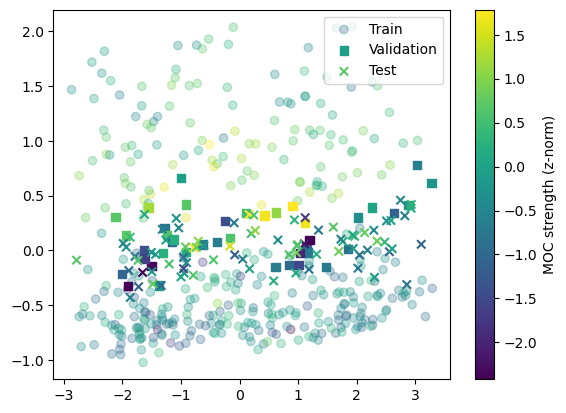

In [26]:
def get_means(dataloader):
    argo_means = []

    moc_strength = []

    for data in dataloader:
        X, mask_padded, y, y_prev, lon, lat, dvdz, days, missing_indices, fs, ac, ws, total_moc = data
        print(X.shape)

        argo_mean = torch.sum(X, dim=1) / torch.sum(mask_padded, dim=1, keepdim=True)

        argo_std = torch.sqrt(((X - argo_mean.unsqueeze(1)) ** 2).sum(dim = 1) / (torch.sum(mask_padded, dim=1, keepdim=True) - 1))

        mask = (argo_std < 5).all(1)


        argo_means.append(argo_mean[mask])
        moc_strength.append(total_moc[mask])
        
    argo_means = torch.cat(argo_means, dim=0)
    moc_strength = torch.cat(moc_strength, dim=0)

    return argo_means, moc_strength


train_argo_means, train_moc_strength = get_means(dl)
val_argo_means, val_moc_strength = get_means(val_dl)
test_argo_means, test_moc_strength = get_means(test_dl)



pca = PCA(n_components=2)

pca.fit(train_argo_means.detach().numpy())
train_reduced_values = pca.transform(train_argo_means.detach().numpy())
val_reduced_values = pca.transform(val_argo_means.detach().numpy())
test_reduced_values = pca.transform(test_argo_means.detach().numpy())

print(pca.explained_variance_ratio_)

# reduced_values = tsne.fit_transform(argo_means.detach().numpy())



plt.scatter(train_reduced_values[:,0], train_reduced_values[:,1], c = train_moc_strength.detach().numpy(), marker='o', label = 'Train', alpha = .3)
plt.scatter(val_reduced_values[:,0], val_reduced_values[:,1], c = val_moc_strength.detach().numpy(), marker='s', label = 'Validation')
plt.scatter(test_reduced_values[:,0], test_reduced_values[:,1], c = test_moc_strength.detach().numpy(), marker='x', label = 'Test')

plt.colorbar(label = 'MOC strength (z-norm)')

plt.legend()

In [ ]:
for data in test_dl:
    X, mask_padded, y, y_prev, lon, lat, dvdz, days, missing_indices, fs, ac, ws, total_moc = data
    print(y.shape, total_moc.shape)

    break

torch.Size([32]) torch.Size([32])
